In [79]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [80]:
df=pd.read_csv('housing.csv')

In [81]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [82]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [83]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Text(0.5, 1.0, 'Median imputation')

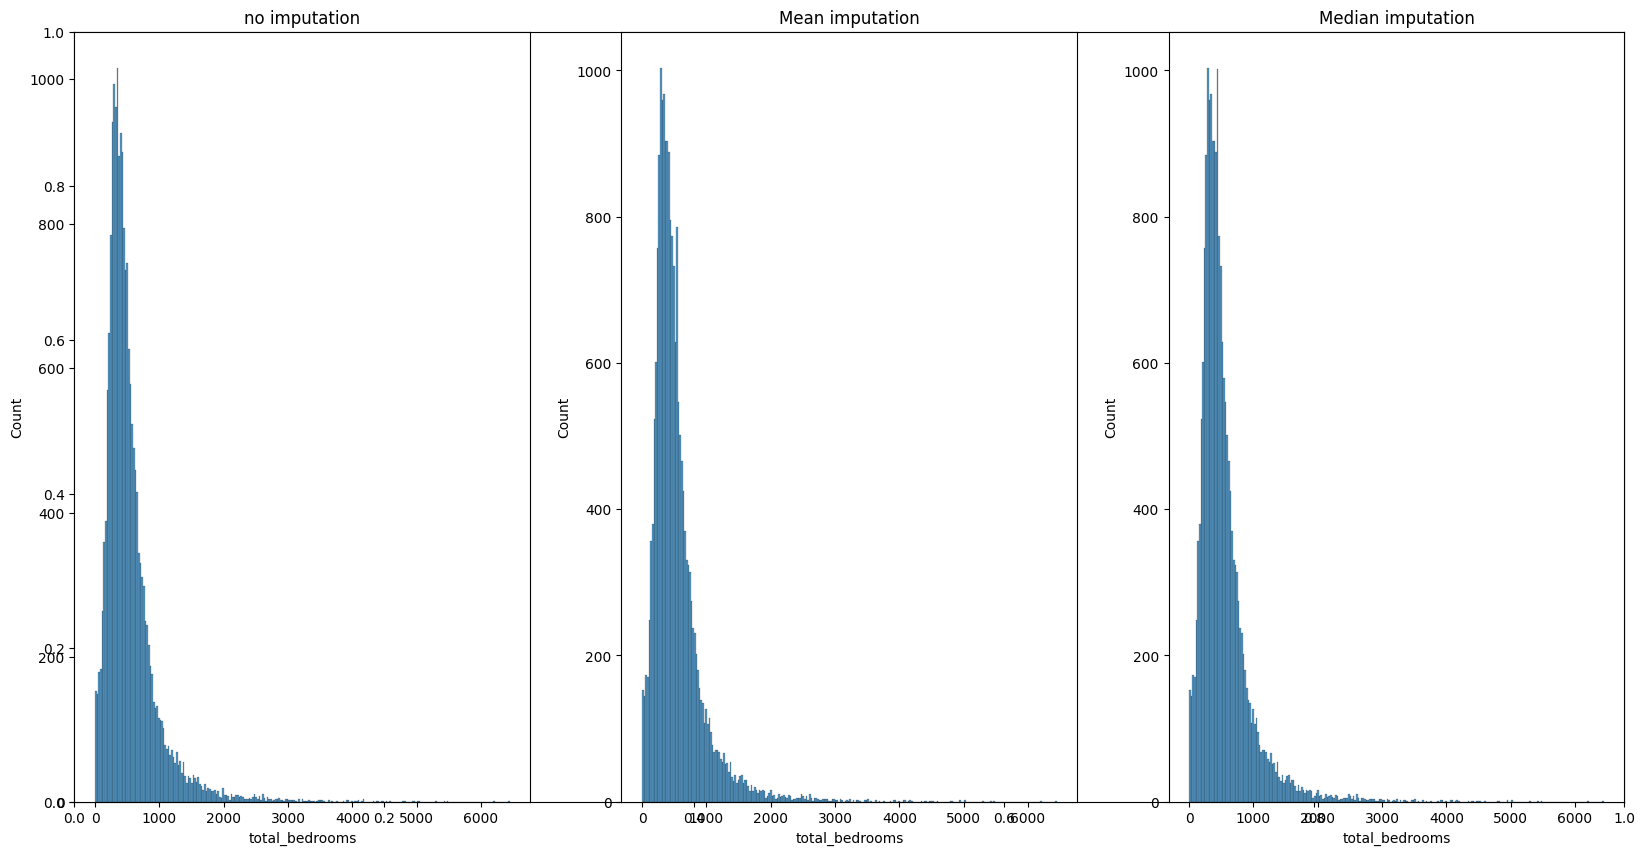

In [84]:
plt.subplots(figsize=(20,10))
plt.subplot(1,3,1)
sns.histplot(df['total_bedrooms'])
plt.title("no imputation")
plt.subplot(1,3,2)
sns.histplot(df['total_bedrooms'].fillna(df['total_bedrooms'].mean()))
plt.title("Mean imputation")
plt.subplot(1,3,3)
sns.histplot(df['total_bedrooms'].fillna(df['total_bedrooms'].median()))
plt.title("Median imputation")

In [85]:

df['total_bedrooms'].median()

np.float64(435.0)

In [86]:
df['total_bedrooms'].mean()

np.float64(537.8705525375618)

In [87]:
df['total_bedrooms'].count()

np.int64(20433)

In [88]:
df['total_bedrooms']=df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [89]:
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [90]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [91]:
corr1=df.drop(columns=['ocean_proximity']).corr()
corr1

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069120,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066484,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.319026,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.927058,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069120,-0.066484,-0.319026,0.927058,1.000000,0.873535,0.974366,-0.007617,0.049457
population,0.099773,-0.108785,-0.296244,0.857126,0.873535,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.974366,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007617,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049457,-0.024650,0.065843,0.688075,1.000000


<Axes: >

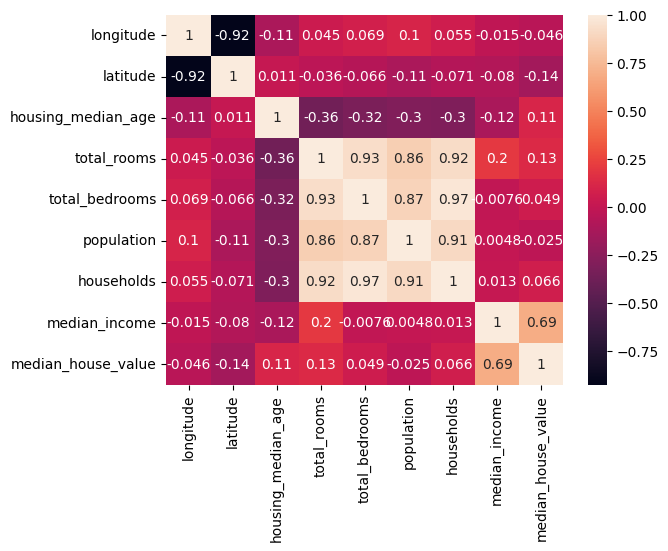

In [92]:
sns.heatmap(corr1,annot=True)

In [93]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

In [94]:
df = df.drop(columns=[
    'total_rooms',
    'total_bedrooms',
    'population',
    'households'
])

In [95]:
from sklearn.preprocessing import OneHotEncoder

In [96]:
encoder=OneHotEncoder(drop='first')

In [97]:
encoded=encoder.fit_transform(df[['ocean_proximity']]).toarray() ## or add spare_ouput=false in encoder

In [98]:
ocean=pd.DataFrame(encoded,columns=encoder.get_feature_names_out())

In [99]:
df=pd.concat([df,ocean],axis=1)

In [100]:
df

,longitude,latitude,housing_median_age,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1.5603,78100.0,INLAND,5.045455,0.224625,2.560606,1.0,0.0,0.0,0.0
20636,-121.21,39.49,18.0,2.5568,77100.0,INLAND,6.114035,0.215208,3.122807,1.0,0.0,0.0,0.0
20637,-121.22,39.43,17.0,1.7000,92300.0,INLAND,5.205543,0.215173,2.325635,1.0,0.0,0.0,0.0
20638,-121.32,39.43,18.0,1.8672,84700.0,INLAND,5.329513,0.219892,2.123209,1.0,0.0,0.0,0.0


In [101]:
df.drop(columns='ocean_proximity',inplace=True)

In [102]:
df

,longitude,latitude,housing_median_age,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,8.3252,452600.0,6.984127,0.146591,2.555556,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,8.3014,358500.0,6.238137,0.155797,2.109842,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,7.2574,352100.0,8.288136,0.129516,2.802260,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,5.6431,341300.0,5.817352,0.184458,2.547945,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,3.8462,342200.0,6.281853,0.172096,2.181467,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1.5603,78100.0,5.045455,0.224625,2.560606,1.0,0.0,0.0,0.0
20636,-121.21,39.49,18.0,2.5568,77100.0,6.114035,0.215208,3.122807,1.0,0.0,0.0,0.0
20637,-121.22,39.43,17.0,1.7000,92300.0,5.205543,0.215173,2.325635,1.0,0.0,0.0,0.0
20638,-121.32,39.43,18.0,1.8672,84700.0,5.329513,0.219892,2.123209,1.0,0.0,0.0,0.0


In [103]:
df.drop(columns='median_house_value')

,longitude,latitude,housing_median_age,median_income,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,8.3252,6.984127,0.146591,2.555556,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,8.3014,6.238137,0.155797,2.109842,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,7.2574,8.288136,0.129516,2.802260,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,5.6431,5.817352,0.184458,2.547945,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,3.8462,6.281853,0.172096,2.181467,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1.5603,5.045455,0.224625,2.560606,1.0,0.0,0.0,0.0
20636,-121.21,39.49,18.0,2.5568,6.114035,0.215208,3.122807,1.0,0.0,0.0,0.0
20637,-121.22,39.43,17.0,1.7000,5.205543,0.215173,2.325635,1.0,0.0,0.0,0.0
20638,-121.32,39.43,18.0,1.8672,5.329513,0.219892,2.123209,1.0,0.0,0.0,0.0


In [104]:
X=df.drop(columns='median_house_value')
y=df['median_house_value']

In [105]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [106]:
# scaling 
from sklearn.preprocessing import StandardScaler
Scaler=StandardScaler() # to get gradient descent quickly 

In [107]:
X_train_scaled=Scaler.fit_transform(X_train)
X_test_scaled=Scaler.transform(X_test)

In [108]:
from sklearn.linear_model import LinearRegression

In [109]:
model=LinearRegression()

In [110]:
model.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [111]:
y_pred=model.predict(X_test_scaled)

In [113]:
model.coef_ #slope 

array([-53671.00299438, -52572.44504292,  11216.53318907,  81716.95687217,
         8147.56172061,  19549.368302  ,  -4006.11929815, -16573.06331247,
         2171.73795387,    978.16564777,   2823.06281385])

In [114]:
model.intercept_

np.float64(207194.6937378879)

In [115]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred) # or np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print("mse = ",mse)
print("mae = ",mae)
print("rmse = ",rmse)
print("r2 = ",r2)

mse =  5856932560.983568
mae =  53132.664917343995
rmse =  76530.59885420711
r2 =  0.5530454493034727


In [116]:
n=X_train_scaled.shape[0]
p=X_train_scaled.shape[1]

In [117]:
Adjr2= 1-(((1-r2)*(n-1))/(n-p-1))

In [118]:
Adjr2

0.5527474796030083

Text(0, 0.5, 'Residuals')

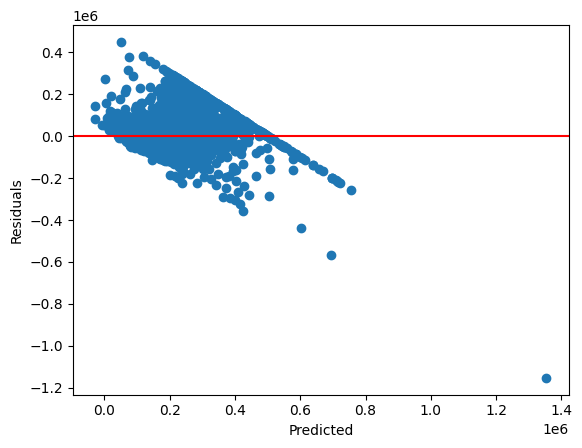

In [ ]:
### To check ASSUMPTIONS such as linearity independence no multicolllinearity etc 
residuals = y_test - y_pred
## Residuals centered around zero good model
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r')
plt.xlabel("Predicted")
plt.ylabel("Residuals")

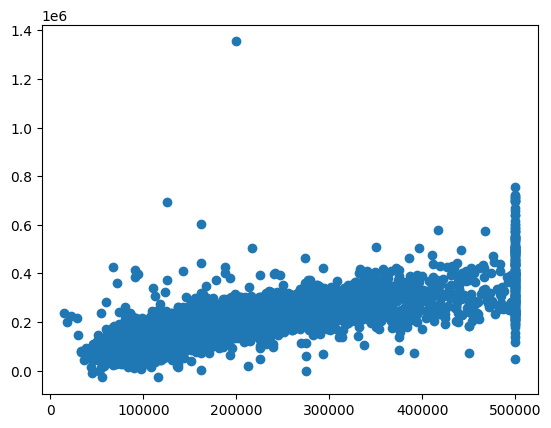

In [122]:
plt.scatter(y_test,y_pred)

<Axes: xlabel='median_house_value', ylabel='Count'>

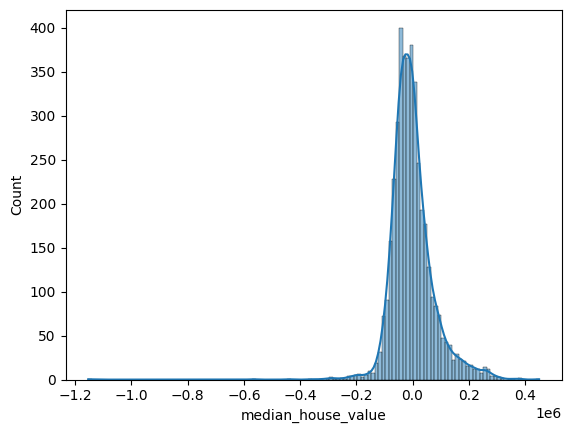

In [ ]:
sns.histplot(residuals, kde=True) # check if they follow normal distribution ## errors centered near zero means no heavy errors

In [ ]:
df.to_csv('Dubai.csv')

In [123]:
### Saving your trained machine learning model to a file so you can reuse it later without training again 
## Pickling model 

In [ ]:
# convert to pkl file 
import pickle 
pickle.dump(model,open('model.pkl','wb'))

In [125]:
## load the pickle file 
model = pickle.load(open('model.pkl','rb'))

In [129]:
y_test

20046     47700.0
3024      45800.0
15663    500001.0
20484    218600.0
9814     278000.0
           ...   
15362    263300.0
16623    266800.0
18086    500001.0
2144      72300.0
3665     151500.0
Name: median_house_value, Length: 4128, dtype: float64

In [128]:
model.predict(X_test_scaled)

array([ 79381.63905586, 110690.33137596, 209304.44271986, ...,
       446994.9213154 , 108555.88944023, 205589.30276287], shape=(4128,))